# Preliminaries

In [2]:
import numpy as np
import numpy.polynomial.polynomial as poly

import matplotlib.pyplot as plt
from matplotlib import cm, ticker
from matplotlib.ticker import FormatStrFormatter

import scipy.constants as const
from scipy.signal import fftconvolve, welch

import pycbc.psd, pycbc.filter, pycbc.noise
from pycbc.types import TimeSeries

plt.rcParams['text.usetex'] = True

#define the solar mass in [kg] and parsec in [meters]
sol = 1.989e30
pc = 3.086e16

/opt/anaconda3/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


In [3]:
#for the waveforms of the quasi-circular binary system and quasi-circular Lagrange triple
import waveforms

print(waveforms.CircularBinary.__doc__)
print(waveforms.CircularLagrangeTriple.__doc__)

CircularBinary contains the waveforms for a quasi-circular binary system up to the 0.5-PN approximation.
    Upon initialization, the user must supply the following parameters of the binary:

    l = initial separation distance in [pc],
    m1, m2 = masses of the individual masses in [solar mass],
    r = distance to the binary system in [pc],
    i_deg = orbital inclination angle in [deg],
    phi = integration constant corresponding to the value of the phase at coalescence [rad]
    

    CircularLagrangeTriple contains the waveforms for a quasi-circular Lagrange three-body system up to the 0.5-PN approximation.
    Upon initialization, the user must supply the following parameters of the binary:

    l = initial separation distance in [pc],
    m1, m2, m3 = masses of the individual masses in [solar mass],
    r = distance to the binary system in [pc],
    i_deg = orbital inclination angle in [deg],
    phi = integration constant corresponding to the value of the phase at coalescence

# 1: Chirp Mass and Stability of the Lagrange Triple

The expression for the chirp mass of the Lagrange triple is

$$
M_{(\mathrm{3B})} = \mathcal{M}_{(\mathrm{3B})} \Bigl[ \frac{\beta_1\beta_2 + \beta_1\beta_3 + \beta_2\beta_3}{(\beta_1\beta_2 + \beta_2\beta_3 + \beta_1\beta_3)^2 - 3(\beta_1^2\beta_2\beta_3 + \beta_1\beta_2^2\beta_3 + \beta_1\beta_2\beta_3^2)} \Bigr]^{3/5}
$$

This is equivalent to the definition of Asada (2009). Using $\beta_3 = 1 - \beta_1 - \beta_2$, we can plot the total mass $M_{(\mathrm{3B})}$ as a function of the mass ratios $\beta_1$ and $\beta_2$, assuming we know the chirp mass of the Lagrange triple.

/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_75067/2937776525.py:2: RuntimeWarning: divide by zero encountered in divide
  return (0.5 * ((b1**2)*(b2 - b3)**2 + (b2**2)*(b3 - b1)**2 + (b3**2)*(b1 - b2)**2)/(b1*b2 + b1*b3 + b2*b3))**(-3/5)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_75067/2937776525.py:2: RuntimeWarning: invalid value encountered in divide
  return (0.5 * ((b1**2)*(b2 - b3)**2 + (b2**2)*(b3 - b1)**2 + (b3**2)*(b1 - b2)**2)/(b1*b2 + b1*b3 + b2*b3))**(-3/5)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_75067/2937776525.py:2: RuntimeWarning: invalid value encountered in power
  return (0.5 * ((b1**2)*(b2 - b3)**2 + (b2**2)*(b3 - b1)**2 + (b3**2)*(b1 - b2)**2)/(b1*b2 + b1*b3 + b2*b3))**(-3/5)


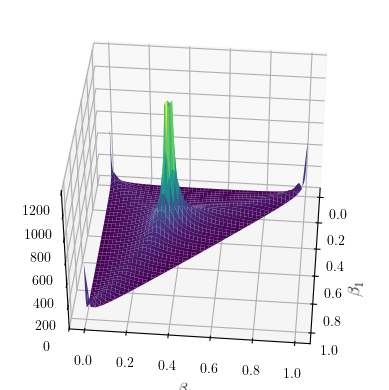

In [6]:
def M_chirp_betas(b1, b2, b3):
    return (0.5 * ((b1**2)*(b2 - b3)**2 + (b2**2)*(b3 - b1)**2 + (b3**2)*(b1 - b2)**2)/(b1*b2 + b1*b3 + b2*b3))**(-3/5)

fig = plt.figure()
ax = fig.add_subplot(projection = "3d")
b1 = np.linspace(0, 1, 1000)
b2 = np.linspace(0, 1, 1000)
b1_grid, b2_grid = np.meshgrid(b1, b2)

M_c_betas = M_chirp_betas(b1_grid, b2_grid, 1 - b1_grid - b2_grid)
M_c_betas[b1_grid + b2_grid > 1] = np.nan
M_c_betas[M_c_betas > 150] = np.nan

surf = ax.plot_surface(b1_grid, b2_grid, 8*M_c_betas, linewidth = 0, cmap=cm.viridis, antialiased = True)

ax.set_xlabel(r"$\beta_1$", fontsize = "large")
ax.set_ylabel(r"$\beta_2$", fontsize = "large")
#ax.set_zlabel(r"$M_{(\mathrm{3B})}$", fontsize = "large", rotation = 90)

#ax.set_zlim(0, 150)
ax.zaxis.labelpad = -1

ax.grid()
ax.view_init(40, 5)
plt.show()

/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_75067/1845057184.py:2: RuntimeWarning: divide by zero encountered in divide
  return (0.5 * ((b1**2)*(b2 - b3)**2 + (b2**2)*(b3 - b1)**2 + (b3**2)*(b1 - b2)**2)/(b1*b2 + b1*b3 + b2*b3))**(-3/5)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_75067/1845057184.py:2: RuntimeWarning: invalid value encountered in divide
  return (0.5 * ((b1**2)*(b2 - b3)**2 + (b2**2)*(b3 - b1)**2 + (b3**2)*(b1 - b2)**2)/(b1*b2 + b1*b3 + b2*b3))**(-3/5)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_75067/1845057184.py:2: RuntimeWarning: invalid value encountered in power
  return (0.5 * ((b1**2)*(b2 - b3)**2 + (b2**2)*(b3 - b1)**2 + (b3**2)*(b1 - b2)**2)/(b1*b2 + b1*b3 + b2*b3))**(-3/5)


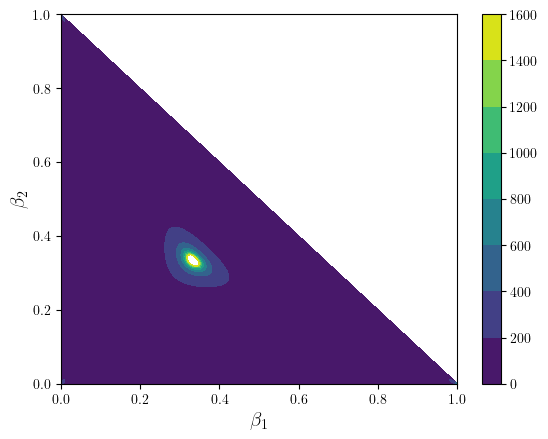

In [7]:
def M_chirp_betas(b1, b2, b3):
    return (0.5 * ((b1**2)*(b2 - b3)**2 + (b2**2)*(b3 - b1)**2 + (b3**2)*(b1 - b2)**2)/(b1*b2 + b1*b3 + b2*b3))**(-3/5)

fig, ax = plt.subplots()
b1 = np.linspace(0, 1, 1000)
b2 = np.linspace(0, 1, 1000)
b1_grid, b2_grid = np.meshgrid(b1, b2)

M_c_betas = M_chirp_betas(b1_grid, b2_grid, 1 - b1_grid - b2_grid)
M_c_betas[b1_grid + b2_grid > 1] = np.nan
M_c_betas[M_c_betas > 200] = np.nan

countour_totalMass = ax.contourf(b1_grid, b2_grid, 8*M_c_betas, cmap=cm.viridis)

ax.set_xlabel(r"$\beta_1$", fontsize = "x-large")
ax.set_ylabel(r"$\beta_2$", fontsize = "x-large")
cbar = fig.colorbar(countour_totalMass)

plt.show()

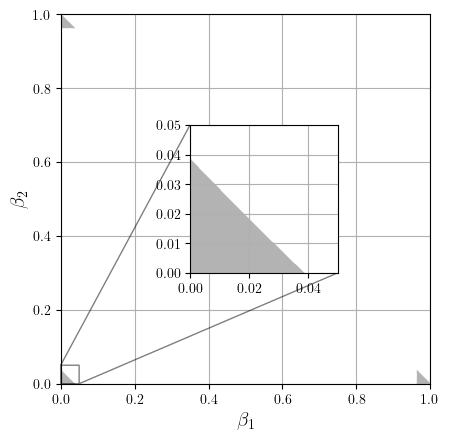

In [8]:
b1 = np.linspace(0, 1, 5000)
b2 = np.linspace(0, 1, 5000)
b1_grid, b2_grid = np.meshgrid(b1, b2)

stability = b1_grid*b2_grid + (b1_grid + b2_grid)*(1 - b1_grid - b2_grid) < 1/27
physicalMassRatios = b1_grid + b2_grid <= 1

fig, ax = plt.subplots()

#plot the stability region
ax.imshow( (stability & physicalMassRatios).astype(float), 
            extent=(b1_grid.min(), b1_grid.max(), b2_grid.min(), b2_grid.max()), 
            origin = "lower", cmap = "Greys", alpha=0.3)

ax.set_xlabel(r"$\beta_1$", fontsize = "x-large")
ax.set_ylabel(r"$\beta_2$", fontsize = "x-large")
ax.grid(True)

#inset plot
axins = ax.inset_axes([0.3, 0.3, 0.5, 0.4], xlim = (0, 0.05), ylim = (0, 0.05))
axins.imshow( (stability & physicalMassRatios).astype(float), 
            extent=(b1_grid.min(), b1_grid.max(), b2_grid.min(), b2_grid.max()), 
            origin = "lower", cmap = "Greys", alpha=0.3)
axins.grid(True)
ax.indicate_inset_zoom(axins, edgecolor = "black")

plt.savefig("LaTeX Files/Figures/System Configuration/Stability of the Lagrange Triple.pdf", bbox_inches = "tight")
plt.show()

# 2: Waveform Degeneracy up to the Mass Quadrupole

In [10]:
def findQuadDegeneracy(a, m1_2B, m2_2B, r_2B, i_2B, M_3B, beta_1):
    M_3B *= sol
    
    binary = waveforms.CircularBinary(a, m1_2B, m2_2B, r_2B, i_2B, 0)
    w_2B = np.sqrt(const.G*binary.M/(binary.l**3))

    r_3B = (binary.r*((const.G*M_3B/(const.c**2))**(5/3))*beta_1*np.abs(3*beta_1 - 1))/((const.G*binary.M_c/(const.c**2))**(5/3))
    b = (const.G*M_3B/(w_2B**2))**(1/3)

    #return b and r_3B in [pc]
    return b/pc, r_3B/pc

In [11]:
params_2B = [150e-13, 10, 8, 2e6, 30, 0]
binary = waveforms.CircularBinary(*params_2B)
print("Binary chirp mass in solar mass = {}".format(binary.M_c/sol))

Binary chirp mass in solar mass = 7.776774233174123


/opt/anaconda3/lib/python3.11/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


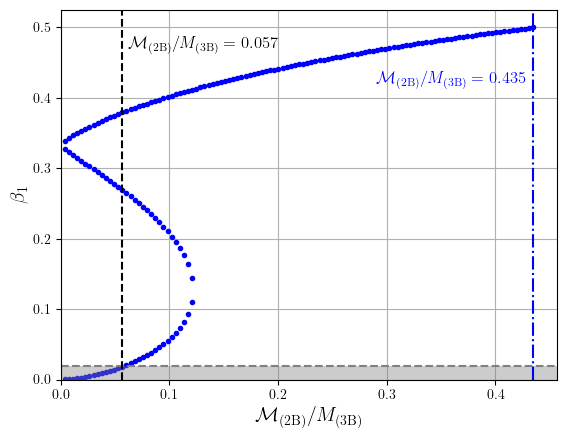

In [12]:
a1 = np.linspace(0, 0.45, 120)

#plt.figure(figsize = (10,5))

checkLastStableValue = 0
checkAllowedValues = []

for val in a1:
    temp = poly.polyroots([-8*(val**5), 36*(val**5), -54*(val**5), 1 + 27*val**5, -18, 135, -540, 1215, -1458, 729])
    temp = temp[np.isclose(temp.imag, 0)]
    temp = temp[temp > 0]

    for root in temp:
        if root <= 0.5:
            plt.scatter(val, root, color = "blue", marker = ".")

            if val not in checkAllowedValues:
                checkAllowedValues.append(val)
    
    if len(temp) > 0 and np.min(temp) < np.min(np.roots([-3, 2, -1/27])):
        checkLastStableValue = val

plt.xlabel(r"$\mathcal{M}_{\mathrm{(2B)}}/M_{\mathrm{(3B)}}$", fontsize = "x-large")
plt.ylabel(r"$\beta_1$", fontsize = "x-large")
plt.grid()
plt.gca().set_axisbelow(True)
plt.ylim(0)
plt.xlim(0)

#plot stability regions
plt.axhspan(0, np.min(np.roots([-3, 2, -1/27])), facecolor = "gray", alpha = 0.4)
plt.axhline(np.min(np.roots([-3, 2, -1/27])), color = "gray", ls = "--")
plt.axvline(checkAllowedValues[-1], color = "blue", ls = "-.")
plt.annotate(r"$\mathcal{{M}}_{{\mathrm{{(2B)}}}}/M_{{\mathrm{{(3B)}}}} = {:.3f}$".format(checkAllowedValues[-1]),
             xy = (checkAllowedValues[-1] - 0.145, 0.42), fontsize = 12, color = "blue")
plt.axvline(checkLastStableValue, color = "black", ls = "--")
plt.annotate(r"$\mathcal{{M}}_{{\mathrm{{(2B)}}}}/M_{{\mathrm{{(3B)}}}} = {:.3f}$".format(checkLastStableValue),
             xy = (checkLastStableValue + 0.005, 0.47), fontsize = 12)

plt.savefig("LaTeX Files/Figures/Chirp Mass/Roots of G(beta_1).pdf", bbox_inches = "tight")
plt.show()

/Users/cjdoctolero/Documents/College Stuff/Research/BS Physics Thesis/waveforms.py:52: RuntimeWarning: invalid value encountered in power
  return (5**(3/8))/8 * ((const.G*self.M_c/(const.c**3))**(-5/8)) * (self.t_c - t)**(-3/8)
/Users/cjdoctolero/Documents/College Stuff/Research/BS Physics Thesis/waveforms.py:56: RuntimeWarning: invalid value encountered in power
  return -(5**(-5/8)) * ((const.G*self.M_c/(const.c**3))**(-5/8)) * (self.t_c - t)**(5/8)


Binary Parameters:
l = 1.5e-11, m1 = 10, m2 = 8, r = 2000000.0, i = 30, phi = 0

Lagrange Three-Body Parameters:
l = 2.8231080866430836e-11, m1 = 1.7999999999999998, m2 = 1.7999999999999998, m3 = 116.39999999999999, r = 2740065.1206373814, i = 30, phi = 0.5585053606381855

Binary Coalescence: 0.6446118194246172
Lagrange Triple Coalescence: 0.9631873402104029



(np.float64(nan), np.float64(nan))

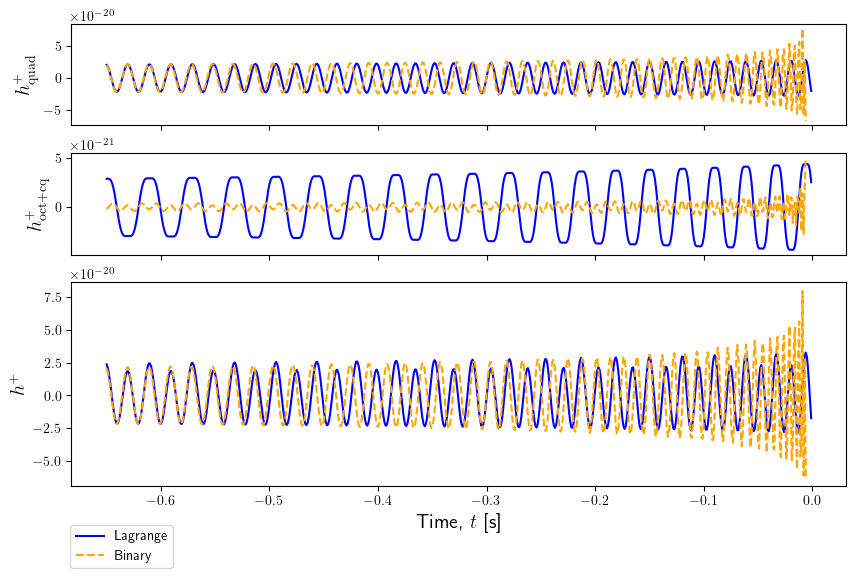

In [13]:
delta_t = 1/1000
t_max = 0.65

beta_1 = 0.015
M_3B = 120
quad_result = findQuadDegeneracy(*params_2B[:5], M_3B, beta_1)
params_3B_quad1 = [quad_result[0], M_3B*beta_1, M_3B*beta_1, M_3B*(1 - 2*beta_1), quad_result[1], 30, np.radians(32)]

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t)
hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_quad1, t_max = t_max, delta_t = delta_t)

waveforms.plot_waveform_time(params_2B, params_3B_quad1, t_max = t_max, delta_t = delta_t, radRxn = True,
                             size = "horizontal", 
                             filename = "LaTeX Files/Figures/Quadrupole Degeneracy/Quadrupole degeneracy 2 (Horizontal).pdf")

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_quad1).t_c))
print("")

f_lower = 0
psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B) // 2 + 1, 1.0 / hp_2B.duration, f_lower)

pycbc.filter.match(hp_2B, hp_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)

/Users/cjdoctolero/Documents/College Stuff/Research/BS Physics Thesis/waveforms.py:195: RuntimeWarning: invalid value encountered in power
  return (5**(3/8))/8 * ((const.G*self.M_c/(const.c**3))**(-5/8)) * (self.t_c - t)**(-3/8)
/Users/cjdoctolero/Documents/College Stuff/Research/BS Physics Thesis/waveforms.py:199: RuntimeWarning: invalid value encountered in power
  return -(5**(-5/8)) * ((const.G*self.M_c/(const.c**3))**(-5/8)) * (self.t_c - t)**(5/8)


Binary Parameters:
l = 1.5e-11, m1 = 10, m2 = 8, r = 2000000.0, i = 30, phi = 0

Lagrange Three-Body Parameters:
l = 3.0411009977866976e-11, m1 = 2.3231939027306483, m2 = 2.3231939027306483, m3 = 145.3536121945387, r = 4097455.9368759324, i = 30, phi = 3.141592653589793

Binary Coalescence: 0.6446118194246172
Lagrange Triple Coalescence: 0.6446118194246188



(np.float64(nan), np.float64(nan))

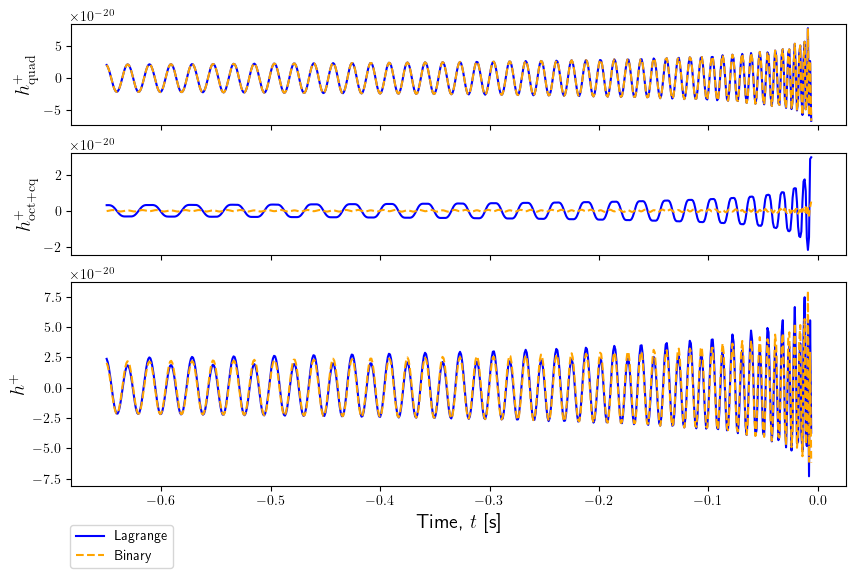

In [14]:
M_3B = 150
val = (waveforms.CircularBinary(*params_2B).M_c/sol)/M_3B

temp = poly.polyroots([-8*(val**5), 36*(val**5), -54*(val**5), 1 + 27*val**5, -18, 135, -540, 1215, -1458, 729])
temp = temp[np.isclose(temp.imag, 0)]
temp = temp[temp > 0]

beta_1 = np.real(np.min(temp))
quad_result = findQuadDegeneracy(*params_2B[:5], M_3B, beta_1)
params_3B_quad4 = [quad_result[0], M_3B*beta_1, M_3B*beta_1, M_3B*(1 - 2*beta_1), quad_result[1], 30, np.radians(180)]

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t)
hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_quad4, t_max = t_max, delta_t = delta_t)

waveforms.plot_waveform_time(params_2B, params_3B_quad4, t_max = t_max, delta_t = delta_t, radRxn = True,
                             size = "horizontal",
                             filename = "LaTeX Files/Figures/Quadrupole Degeneracy/Quadrupole degeneracy 4 (Horizontal).pdf")

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_quad4).t_c))
print()

f_lower = 0
psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B) // 2 + 1, 1.0 / hp_2B.duration, f_lower)

pycbc.filter.match(hp_2B, hp_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)

# 3: Waveform Degeneracy up to the 0.5PN

In [16]:
def F(b1, b2):
    num = 3*((b1 + b2 - 1)**2)*((2*b1**2 + (b1 + b2)*(2*b2 - 1))**2) + (b1 - 3*b1**2 + 2*b1**3 + b2*(b2*(3 - 2*b2) - 1))**2
    denom = 27*(b1**2)*(b2**2)*((b1 + b2 - 1)**2) + ((b1 - b2)**2)*((2*b1 + b2 - 1)**2)*((b1 + 2*b2 - 1)**2)

    return np.sqrt(num/denom)

def iota(b1, b2, ratio_w_3w):
    return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))

def iota_arccos(b1, b2, ratio_w_3w):
    return np.degrees(np.arccos(np.sqrt( 4/((27/2)*ratio_w_3w/F(b1, b2) - 1) - 9) ))

def find_M_3B(a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B, b1):
    binary = waveforms.CircularBinary(a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B)
    
    #quantities obtainable from the known binary system
    amp_quadPlus_2B = binary.h_quad(t_max = 100, ampOnly = True, pol = "plus")
    amp_octcqPlus_2B_w = binary.h_octcq(t_max = 100, ampOnly = True, pol = "plus")[0]
    amp_octcqPlus_2B_3w = binary.h_octcq(t_max = 100, ampOnly = True, pol = "plus")[1]
    w_2B = np.sqrt(const.G*(m1_2B*sol + m2_2B*sol)/((a*pc)**3))

    #parameters obtainable from the equivalent Lagrange triple
    b3 = 1 - 2*b1
    i_3B = np.radians(iota(b1, b1, amp_octcqPlus_2B_w/amp_octcqPlus_2B_3w))

    term1 = (np.sqrt(3)*b3/8)*(amp_quadPlus_2B/amp_octcqPlus_2B_w)*(np.sin(i_3B)*(5 + np.cos(i_3B)**2)/(1 + np.cos(i_3B)**2))*((w_2B/const.c)**(1/3))
    term2 = (9*np.sqrt(27)/8)*(b1*b3/np.abs(b1 - b3))*(amp_quadPlus_2B/amp_octcqPlus_2B_3w)*np.sin(i_3B)*((w_2B/const.c)**(1/3))

    return ((const.c**2)/const.G) * ((1/2)*(term1**(-3)) + (1/2)*(term2**(-3)))

def find_r(a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B, b1):
    t = np.linspace(0, 1000, 10000)
    binary = waveforms.CircularBinary(a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B)
    
    #quantities obtainable from the known binary system
    amp_quadPlus_2B = binary.h_quad(t_max = 100, ampOnly = True, pol = "plus")
    amp_octcqPlus_2B_w = binary.h_octcq(t_max = 100, ampOnly = True, pol = "plus")[0]
    amp_octcqPlus_2B_3w = binary.h_octcq(t_max = 100, ampOnly = True, pol = "plus")[1]
    w_2B = np.sqrt(const.G*(m1_2B*sol + m2_2B*sol)/((a*pc)**3))

    #parameters obtainable from the equivalent Lagrange triple
    i_3B = np.radians(iota(b1, b1, amp_octcqPlus_2B_w/amp_octcqPlus_2B_3w))
    b3 = 1 - 2*b1
    M_3B = find_M_3B(a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B, b1)

    term1 = 2*((const.G*M_3B/(const.c**2))**(5/3))*((w_2B/const.c)**(2/3))*b1*np.abs(b1 - b3)*(1 + np.cos(i_3B)**2)
    term2 = (np.sqrt(3)/4)*((const.G*M_3B/(const.c**2))**2)*(w_2B/const.c)*b1*b3*np.abs(b1 - b3)*np.sin(i_3B)*(5 + np.cos(i_3B)**2)
    term3 = (9*np.sqrt(27)/4)*((const.G*M_3B/(const.c**2))**2)*(w_2B/const.c)*(b1**2)*b3*np.sin(i_3B)*(1 + np.cos(i_3B)**2)
    
    return (term1 + term2 + term3)/(amp_quadPlus_2B + amp_octcqPlus_2B_w + amp_octcqPlus_2B_3w)

def findOctDegeneracy(params_2B, beta_1, filename = "", radRxn = False, suppressPrint = False, atol = 1e-23):
    #initialization
    binary = waveforms.CircularBinary(*params_2B)
    
    #generate the data
    ratio_w_3w = binary.h_octcq(t_max = 10, radRxn = False, ampOnly = True, pol = "plus")[0]/binary.h_octcq(t_max = 10, radRxn = False, ampOnly = True, pol = "plus")[1]
    
    b1 = np.linspace(0, 1, 500000)
    b2 = np.linspace(0, 1, 500000)
    i_3B = iota(b1, b2, ratio_w_3w)
    i_3B[b1 > 0.5] = np.nan
    
    #plot M_3B and r_3B for the given binary system
    #find the values of b1 where i_3B is defined (i.e., the values of b1 that are part of the domain of i_3B)
    b1_filtered = b1[np.where(~np.isnan(i_3B))]

    if suppressPrint == False:
        print("Min beta_1 for true degeneracy = {}".format(b1_filtered[0]))
        print("Max beta_1 for true degeneracy = {}".format(b1_filtered[-1]))

    if b1_filtered[0] < beta_1 < b1_filtered[-1]:
        #calculate the parameters obtainable from the given binary system      
        w_2B = np.sqrt(const.G*(params_2B[1]*sol + params_2B[2]*sol)/((params_2B[0]*pc)**3))

        #find the parameters of the equivalent Lagrange triple
        M_3B = find_M_3B(*params_2B, beta_1)
        r_3B = find_r(*params_2B, beta_1)
        b = (const.G*M_3B/(w_2B**2))**(1/3)
        m1_3B = M_3B*beta_1
        m3_3B = M_3B - 2*m1_3B
        i_3B_deg = iota(beta_1, beta_1, ratio_w_3w)

        delta_t = 1/5000
        t_max = 3
        phi_3B = 0
        shift = np.linspace(0, 2*np.pi, 1000)

        for phi in shift:
            temp = [b/pc, m1_3B/sol, m1_3B/sol, m3_3B/sol, r_3B/pc, i_3B_deg, phi]
            lagrange = waveforms.CircularLagrangeTriple(*temp)
            check = np.abs(binary.h_octcq(t_max, delta_t, radRxn = True, pol = "plus")[:4] - lagrange.h_octcq(t_max, delta_t, radRxn = True, pol = "plus")[:4])
            
            if all(np.isclose(check, 0, atol = atol)):
                phi_3B = phi

        #compile the parameters of the triple into one list
        return [b/pc, m1_3B/sol, m1_3B/sol, m3_3B/sol, r_3B/pc, i_3B_deg, phi_3B]
    else:
        print("Mass ratio not in the region for true degeneracy.")

[0.15909232 0.15909432 0.15909632 ... 0.2011444  0.2011464  0.2011484 ]


/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_75067/2973557677.py:5: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(num/denom)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_75067/2973557677.py:8: RuntimeWarning: invalid value encountered in sqrt
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_75067/2973557677.py:8: RuntimeWarning: invalid value encountered in arcsin
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))


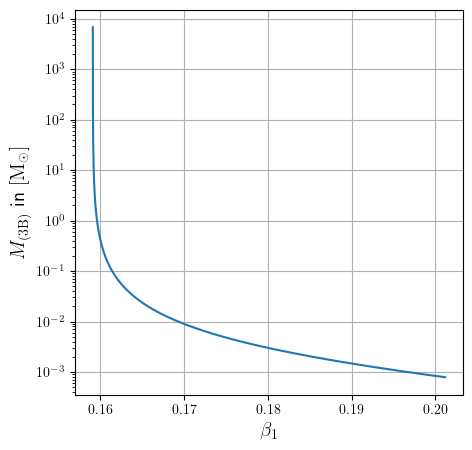

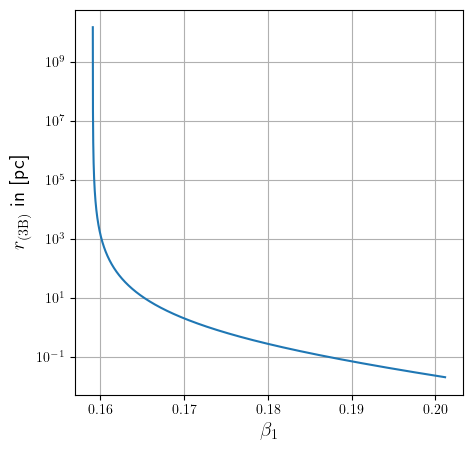

In [17]:
#generate the data
ratio_w_3w = ratio_w_3w = binary.h_octcq(t_max = 10, radRxn = False, ampOnly = True, pol = "plus")[0]/binary.h_octcq(t_max = 10, radRxn = False, ampOnly = True, pol = "plus")[1]

b1 = np.linspace(0, 1, 500000)
b2 = np.linspace(0, 1, 500000)
i_3B = iota(b1, b2, ratio_w_3w)
i_3B[b1 > 0.5] = np.nan

#plot M_3B and r_3B for the given binary system
#find the values of b1 where i_3B is defined (i.e., the values of b1 that are part of the domain of i_3B)
b1_filtered = b1[np.where(~np.isnan(i_3B))]
print(b1_filtered)

start_index = 0

fig = plt.figure(figsize = (5, 5))
plt.plot(b1_filtered[start_index:], find_M_3B(*params_2B, b1_filtered[start_index:])/sol)
plt.xlabel(r"$\beta_1$", fontsize = "x-large")
plt.ylabel(r"$M_{\mathrm{(3B)}}$ in $[\mathrm{M}_{\odot}]$", fontsize = "x-large")
plt.grid()
plt.gca().set_axisbelow(True)
plt.yscale("log")

plt.savefig("LaTeX Files/Figures/0.5PN Degeneracy/M_3B vs beta_1.pdf", bbox_inches = "tight")
plt.show()

fig = plt.figure(figsize = (5, 5))
plt.plot(b1_filtered[start_index:], find_r(*params_2B, b1_filtered[start_index:])/pc)
plt.xlabel(r"$\beta_1$", fontsize = "x-large")
plt.ylabel(r"$r_{\mathrm{(3B)}}$ in [pc]", fontsize = "x-large")
plt.grid()
plt.gca().set_axisbelow(True)
plt.yscale("log")

plt.savefig("LaTeX Files/Figures/0.5PN Degeneracy/r_3B vs beta_1.pdf", bbox_inches = "tight")
plt.show()

/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_75067/2973557677.py:5: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(num/denom)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_75067/2973557677.py:8: RuntimeWarning: invalid value encountered in sqrt
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_75067/2973557677.py:8: RuntimeWarning: invalid value encountered in arcsin
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))


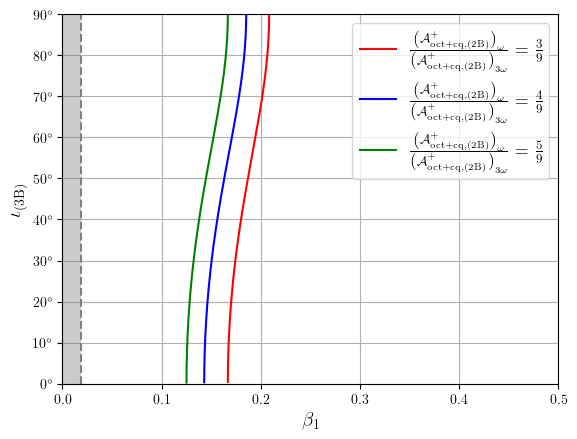

In [39]:
#generate the data
ratios = [3/9, 4/9, 5/9]
b1 = np.linspace(0, 0.5, 200000)

#colors and line styles for plotting
colors = ["Red", "Blue", "Green"]
ratio_labels = [r"$\ \frac{3}{9}$", r"$\ \frac{4}{9}$", r"$\ \frac{5}{9}$"]

for i in range(len(ratios)):
    plt.plot(b1, iota(b1, b1, ratios[i]), color = colors[i],
             label = r"$\frac{\left( \mathcal{A}_{\mathrm{oct+cq,(2B)}}^{+} \right)_{\omega}}{\left( \mathcal{A}_{\mathrm{oct+cq,(2B)}}^{+} \right)_{3\omega}} = $" + ratio_labels[i])

#plot the stability region
plt.axvspan(0, np.min(np.roots([-3, 2, -1/27])), facecolor = "gray", alpha = 0.4)
plt.axvline(np.min(np.roots([-3, 2, -1/27])), color = "gray", ls = "--")

plt.legend(fontsize = 13)
plt.xlabel(r"$\beta_1$", fontsize = "x-large")
plt.ylabel(r"$\iota_{\mathrm{(3B)}}$", fontsize = "x-large")
plt.grid()
plt.gca().set_axisbelow(True)
plt.gca().yaxis.set_major_formatter(FormatStrFormatter("$%d^{\circ}$"))
plt.ylim(0, 90)
plt.xlim(0, 0.5)

plt.savefig("LaTeX Files/Figures/0.5PN Degeneracy/Iota vs Masses (b1 = b2).pdf", bbox_inches = "tight")
plt.show()

/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_75067/2973557677.py:5: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(num/denom)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_75067/2973557677.py:11: RuntimeWarning: invalid value encountered in sqrt
  return np.degrees(np.arccos(np.sqrt( 4/((27/2)*ratio_w_3w/F(b1, b2) - 1) - 9) ))
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_75067/2973557677.py:11: RuntimeWarning: invalid value encountered in arccos
  return np.degrees(np.arccos(np.sqrt( 4/((27/2)*ratio_w_3w/F(b1, b2) - 1) - 9) ))


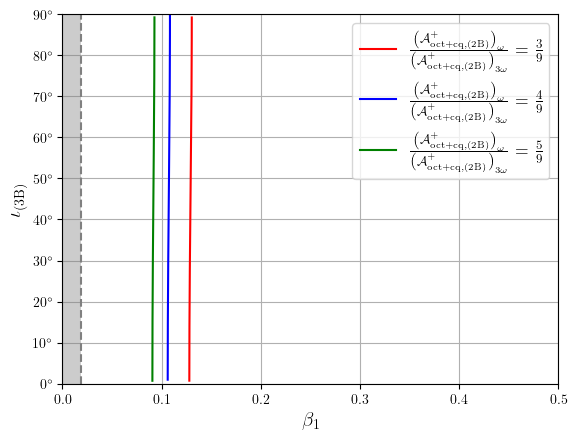

In [19]:
#generate the data
ratios = [3/9, 4/9, 5/9]
b1 = np.linspace(0, 0.5, 500000)

#colors and line styles for plotting
colors = ["Red", "Blue", "Green"]
ratio_labels = [r"$\ \frac{3}{9}$", r"$\ \frac{4}{9}$", r"$\ \frac{5}{9}$"]

for i in range(len(ratios)):
    plt.plot(b1, iota_arccos(b1, b1, ratios[i]), color = colors[i],
             label = r"$\frac{\left( \mathcal{A}_{\mathrm{oct+cq,(2B)}}^{+} \right)_{\omega}}{\left( \mathcal{A}_{\mathrm{oct+cq,(2B)}}^{+} \right)_{3\omega}} = $" + ratio_labels[i])

#plot the stability region
plt.axvspan(0, np.min(np.roots([-3, 2, -1/27])), facecolor = "gray", alpha = 0.4)
plt.axvline(np.min(np.roots([-3, 2, -1/27])), color = "gray", ls = "--")

plt.legend(fontsize = 13)
plt.xlabel(r"$\beta_1$", fontsize = "x-large")
plt.ylabel(r"$\iota_{\mathrm{(3B)}}$", fontsize = "x-large")
plt.grid()
plt.gca().set_axisbelow(True)
plt.gca().yaxis.set_major_formatter(FormatStrFormatter("$%d^{\circ}$"))
plt.ylim(0, 90)
plt.xlim(0, 0.5)

#plt.savefig("LaTeX Files/Figures/0.5PN Degeneracy/Iota vs Masses (b1 = b2).pdf", bbox_inches = "tight")
plt.show()

/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_75067/2973557677.py:5: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(num/denom)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_75067/2973557677.py:8: RuntimeWarning: invalid value encountered in sqrt
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_75067/2973557677.py:8: RuntimeWarning: invalid value encountered in arcsin
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))


Min beta_1 for true degeneracy = 0.15909231818463634
Max beta_1 for true degeneracy = 0.20114840229680458
Binary Parameters:
l = 1.5e-11, m1 = 10, m2 = 8, r = 2000000.0, i = 30, phi = 0

Lagrange Three-Body Parameters:
l = 1.6736391668798657e-11, m1 = 3.9791550608070887, m2 = 3.9791550608070887, m3 = 17.04423502954566, r = 1329846.520426099, i = 2.645330218708403, phi = 3.0252373701235045

Binary Coalescence: 0.6446118194246172
Lagrange Triple Coalescence: 3.224776342568823



(np.float64(0.3561830039581144), np.float64(289.6536715901483))

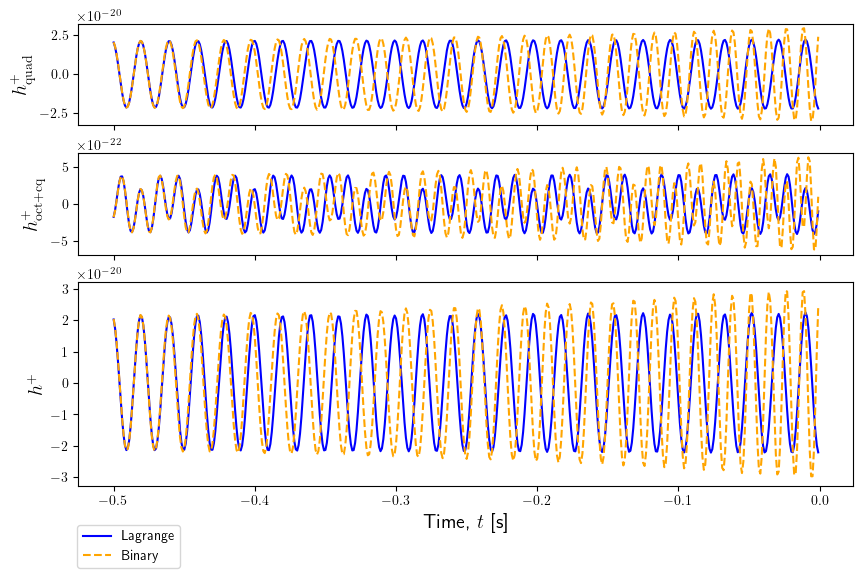

In [20]:
delta_t = 1/1000
t_max = 0.5

params_3B_oct1 = findOctDegeneracy(params_2B, 0.15915)

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t)
hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_oct1, t_max = t_max, delta_t = delta_t)

waveforms.plot_waveform_time(params_2B, params_3B_oct1, t_max = t_max, delta_t = delta_t, radRxn = True, size = "horizontal",
                             filename = "LaTeX Files/Figures/0.5PN Degeneracy/0.5PN degeneracy 1 (Horizontal).pdf")

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_oct1).t_c))
print("")

f_lower = 0
psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B) // 2 + 1, 1.0 / hp_2B.duration, f_lower)

pycbc.filter.match(hp_2B, hp_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)

Min beta_1 for true degeneracy = 0.15909231818463634
Max beta_1 for true degeneracy = 0.20114840229680458


/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_75067/2973557677.py:5: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(num/denom)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_75067/2973557677.py:8: RuntimeWarning: invalid value encountered in sqrt
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_75067/2973557677.py:8: RuntimeWarning: invalid value encountered in arcsin
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))


Binary Parameters:
l = 1.5e-11, m1 = 10, m2 = 8, r = 2000000.0, i = 30, phi = 0

Lagrange Three-Body Parameters:
l = 2.309373805332004e-11, m1 = 10.452291790150664, m2 = 10.452291790150664, m3 = 44.78271991324934, r = 6655437.262202962, i = 1.917277536430065, phi = 3.1573163405446967

Binary Coalescence: 0.6446118194246172
Lagrange Triple Coalescence: 0.644611819425072



(np.float64(nan), np.float64(nan))

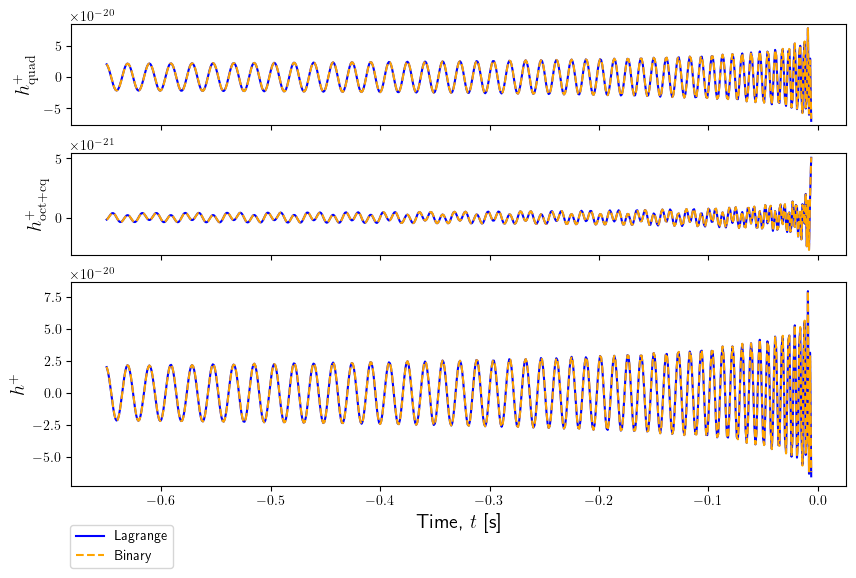

In [21]:
delta_t = 1/1000
t_max = 0.65

params_3B_oct1 = findOctDegeneracy(params_2B, 0.15912194951307287)

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t)
hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_oct1, t_max = t_max, delta_t = delta_t)

waveforms.plot_waveform_time(params_2B, params_3B_oct1, t_max = t_max, delta_t = delta_t, radRxn = True, size = "horizontal",
                            filename = "LaTeX Files/Figures/0.5PN Degeneracy/0.5PN degeneracy 2 (Horizontal).pdf")

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_oct1).t_c))
print("")

f_lower = 0
psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B) // 2 + 1, 1.0 / hp_2B.duration, f_lower)

pycbc.filter.match(hp_2B, hp_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)